# 04. 内積・正射影・最小二乗 — 一番近い影を落とす

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 5. Definition |
| Applied | 6. Computation 〜 10. Exercises |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

ここまでの章には「長さ」も「角度」もありませんでした。
それらを一気に持ち込むのが **内積** です。内積が定義された瞬間に:

- ベクトルの **長さ**(ノルム)と **距離** が測れる
- 2 本のベクトルの **角度**、特に **直交** が定義できる
- 部分空間への **正射影** =「一番近い影」が計算できる

そして正射影の最重要応用が **最小二乗法** です。
**解けない方程式 $Ax = b$ を、「最も近く」解く方法** — データ分析・機械学習の根幹が
この章で全部つながります。

```{admonition} 核心 — ひとことで
:class: tip
**内積は「どれだけ同じ向きか」を測る物差し、正射影は「部分空間の中で $b$ に一番近い点」を選ぶ操作である。**
解けない $Ax=b$ を最も近く解く最小二乗とは、$b$ を列空間 $\mathrm{col}(A)$ へ正射影すること。
残差が列空間と直交する条件 $A^\top(b-A\hat x)=0$ が、そのまま正規方程式 $A^\top A\,\hat x = A^\top b$ になる。
```

## 2. Problem — 解けない方程式をどうするか

実験で 40 組のデータ $(x_i, y_i)$ を測り、直線 $y = c_1 x + c_0$ を当てはめたいとします。
すべての点を通る直線の条件は:

$$
\begin{pmatrix} x_1 & 1 \\ x_2 & 1 \\ \vdots & \vdots \\ x_{40} & 1 \end{pmatrix}
\begin{pmatrix} c_1 \\ c_0 \end{pmatrix}
=
\begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_{40} \end{pmatrix}
$$

方程式 40 本、未知数 2 個。ノイズがある限り、**厳密な解は存在しません**。
でも「全部の点にできるだけ近い直線」は確かに 1 本ある気がします。
「できるだけ近い」を数学にするには、まず「近さ」= 距離が必要です。

## 3. Intuition — 内積は「どれだけ同じ向きか」

内積 $v \cdot w$ の直感は **「$v$ と $w$ がどれだけ同じ方向を向いているか」** です。

- 同じ向き → 正で大きい
- 直角 → ちょうど 0
- 逆向き → 負

「直交 = 内積 0 = 互いに情報を持たない」という感覚が大事です。
レコメンドで「好みが似たユーザー」を探すとき、実際にベクトルの内積(コサイン類似度)を使います。

**正射影** は「$b$ から部分空間に降ろした垂線の足」=「$b$ に一番近い、部分空間の中の点」。
日なたに立つ人の影が、地面という部分空間への正射影です。

In [1]:
# Shared setup.
import numpy as np
import matplotlib.pyplot as plt

from la_book import algebra, plotting
from la_book.datasets import make_noisy_line

np.set_printoptions(precision=4, suppress=True)

In [2]:
# Inner product as alignment: same direction > 0, orthogonal = 0, opposite < 0.
a = np.array([2.0, 1.0])
for w_vec in [np.array([1.0, 0.8]), np.array([-1.0, 2.0]), np.array([-2.0, -0.5])]:
    cos = a @ w_vec / (np.linalg.norm(a) * np.linalg.norm(w_vec))
    print(f"a . w = {a @ w_vec:+.2f}   cos(angle) = {cos:+.3f}   w = {w_vec}")

a . w = +2.80   cos(angle) = +0.978   w = [1.  0.8]
a . w = +0.00   cos(angle) = +0.000   w = [-1.  2.]
a . w = -4.50   cos(angle) = -0.976   w = [-2.  -0.5]


## 4. Visualization — 正射影は「一番近い影」

ベクトル $b$ を直線 $\mathrm{span}\{a\}$ に射影します。
点線(残差)が直線と **直角** になっていることに注目してください。
直角だからこそ、影 $p$ は直線上の点の中で $b$ に一番近いのです
(直角でなければ、足を少しずらすともっと近くなる)。

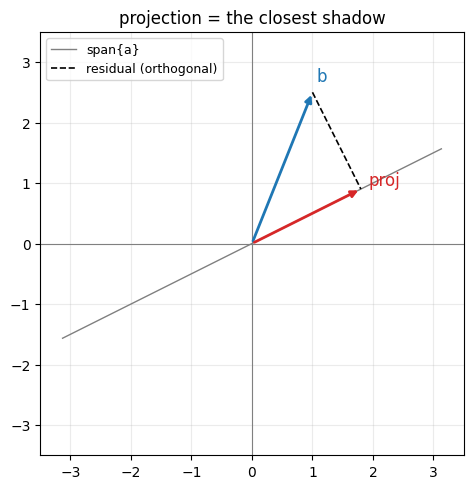

projection p = [1.8 0.9]
residual r = b - p = [-0.8  1.6]
r . a = 0.0  (orthogonal!)


In [3]:
# Orthogonal projection of b onto the line spanned by a.
b_vec = np.array([1.0, 2.5])
plotting.plot_projection(b_vec, a)
plt.title("projection = the closest shadow")
plt.show()

p = (a @ b_vec) / (a @ a) * a
print("projection p =", p)
print("residual r = b - p =", b_vec - p)
print("r . a =", (b_vec - p) @ a, " (orthogonal!)")

### ▶ 触って確かめる — b を回すと影と残差が動く

スライダーで $b$ を円周上に回すと、固定した直線 $\mathrm{span}\{a\}$ への射影（赤）と残差（点線）がどう動くかが見えます。
残差は常に直線と**直角**のまま。スライダーのラベルの内積 $a\cdot b$ は、
$b$ が $a$ と同じ向きで最大、直交で 0、逆向きで負 — 「内積＝どれだけ同じ向きか」が数値と図でぴたりと一致します。

In [4]:
# Sweep b around a circle; projection (red) + residual (dashed) update live.
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"
fig = plotting.plotly_projection_sweep(a=(2.0, 1.0))
fig.show()

## 5. Definition — 内積・ノルム・直交・射影・最小二乗

**内積・ノルム・距離・角度**:

$$
v \cdot w = v^\top w = \sum_i v_i w_i, \qquad
\|v\| = \sqrt{v^\top v}, \qquad
d(v, w) = \|v - w\|, \qquad
\cos\theta = \frac{v^\top w}{\|v\|\,\|w\|}
$$

**直交**: $v^\top w = 0$。**正規直交基底**: 互いに直交し、長さがすべて 1 の基底。

**直線への射影**: $\mathrm{span}\{a\}$ への $b$ の正射影は

$$
p = \frac{a^\top b}{a^\top a}\, a
$$

**部分空間への射影**: $A$ の列が張る空間 $\mathrm{col}(A)$ への射影は、射影行列

$$
P = A (A^\top A)^{-1} A^\top
$$

で $p = Pb$ と書けます。$P^2 = P$(2 回影を落としても変わらない)、$P^\top = P$ が特徴です。

**最小二乗法**: $Ax = b$ が解けないとき、残差のノルムを最小化します。

$$
\hat{x} = \arg\min_x \|Ax - b\|^2
$$

幾何的には「$\mathrm{col}(A)$ の中で $b$ に一番近い点 $A\hat{x}$ を探す」こと、
つまり **$b$ を $\mathrm{col}(A)$ に正射影する** ことと同じです。
残差が列空間と直交する条件 $A^\top (b - A\hat{x}) = 0$ を整理すると **正規方程式**:

$$
A^\top A \,\hat{x} = A^\top b
$$

## 6. Computation — Gram-Schmidt・QR・最小二乗

### Gram-Schmidt 直交化

任意の基底から正規直交基底を作る手続きです。
「2 本目から 1 本目方向の成分(影)を引き算して直交化 → 正規化」の繰り返し。
この手続きを行列の形でまとめたものが **QR 分解** $A = QR$ です(05 章で再登場)。

In [5]:
# Gram-Schmidt turns any independent set into an orthonormal basis.
V = np.array([[1.0, 1.0, 0.0],
              [1.0, 0.0, 1.0],
              [0.0, 1.0, 1.0]]).T
Q = algebra.gram_schmidt(V)
print("Q =\n", Q)
print("Q^T Q =\n", Q.T @ Q)   # identity: orthonormal columns

# numpy's QR does the same job (more stably, via Householder reflections).
Q_np, R_np = np.linalg.qr(V)
print("\nnumpy QR: |R| diagonal =", np.abs(np.diag(R_np)))

Q =
 [[ 0.7071  0.4082 -0.5774]
 [ 0.7071 -0.4082  0.5774]
 [ 0.      0.8165  0.5774]]
Q^T Q =
 [[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

numpy QR: |R| diagonal = [1.4142 1.2247 1.1547]


### 最小二乗で直線フィット

冒頭の問題を解きます。`la_book.algebra.least_squares` は QR 経由で正規方程式を解きます。

fitted slope = 1.776, intercept = 0.562, residual norm = 3.522
(true values were 1.8 and 0.5)


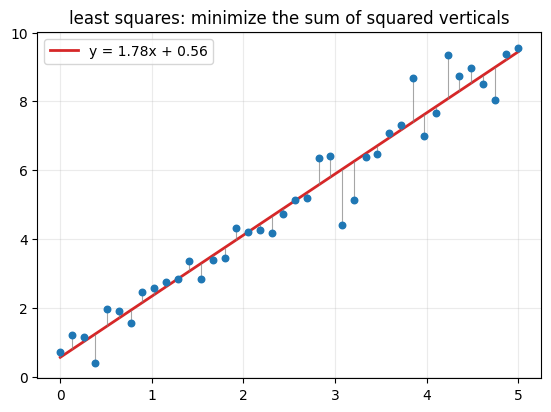

In [6]:
# Fit a line to noisy data: the least squares solution of an unsolvable system.
x_data, y_data = make_noisy_line(n=40, slope=1.8, intercept=0.5, seed=1)
A_ls = np.column_stack([x_data, np.ones_like(x_data)])   # design matrix [x, 1]

coef, res = algebra.least_squares(A_ls, y_data)
print(f"fitted slope = {coef[0]:.3f}, intercept = {coef[1]:.3f}, residual norm = {res:.3f}")
print("(true values were 1.8 and 0.5)")

plotting.plot_least_squares(x_data, y_data, coef, label=f"y = {coef[0]:.2f}x + {coef[1]:.2f}")
plt.title("least squares: minimize the sum of squared verticals")
plt.show()

In [7]:
# The geometry behind it: A x_hat is exactly the projection of b onto col(A).
P_mat = algebra.projection_matrix(A_ls)
p = P_mat @ y_data
print("||A @ coef - P b|| =", np.linalg.norm(A_ls @ coef - p), " (same point)")

# And the residual is orthogonal to every column of A.
r = y_data - p
print("A^T r =", A_ls.T @ r, " (zero vector)")

||A @ coef - P b|| = 1.1680052773710345e-14  (same point)
A^T r = [ 0. -0.]  (zero vector)


## 7. Invariant — 直交変換は長さと角度を保存する

**直交行列** $Q$($Q^\top Q = I$、列が正規直交基底)による変換は:

$$
\|Qv\| = \|v\|, \qquad (Qv)^\top (Qw) = v^\top w
$$

**長さも角度も一切変えません**。回転と鏡映がその正体です。
「形を保つ変換」なので、数値計算では直交行列を使う限り誤差が増幅されません
(06 章で効いてきます)。

もうひとつの保存量はピタゴラスの定理です。射影 $p$ と残差 $r = b - p$ は直交するので:

$$
\|b\|^2 = \|p\|^2 + \|r\|^2
$$

「データの全変動 = 説明できた変動 + 残差の変動」。統計の決定係数 $R^2$ はこの分解そのものです。

In [8]:
# Orthogonal matrices preserve lengths and angles.
rng = np.random.default_rng(0)
Q_orth, _ = np.linalg.qr(rng.standard_normal((3, 3)))   # random orthogonal matrix
u, v = rng.standard_normal(3), rng.standard_normal(3)

print("||u|| =", np.linalg.norm(u), " ||Qu|| =", np.linalg.norm(Q_orth @ u))
print("u.v  =", u @ v, "  (Qu).(Qv) =", (Q_orth @ u) @ (Q_orth @ v))

# Pythagoras for the projection: ||b||^2 = ||p||^2 + ||r||^2.
print("\n||b||^2          =", y_data @ y_data)
print("||p||^2 + ||r||^2 =", p @ p + r @ r)

||u|| = 1.4111946682171774  ||Qu|| = 1.4111946682171772
u.v  = 3.0270226297413423   (Qu).(Qv) = 3.0270226297413396

||b||^2          = 1289.409655661395
||p||^2 + ||r||^2 = 1289.4096556613947


## 8. Failure Mode — 列がほぼ平行だと壊れる

説明変数同士がほぼ平行(強い相関 = **多重共線性**)だと、$A^\top A$ がほぼ特異になり、
係数が暴れます。データをほんの少し変えただけで係数が大きく動く例を見てみます。

In [9]:
# Multicollinearity: two nearly identical columns make coefficients explode.
n = 50
x1 = np.linspace(0, 1, n)
x2 = x1 + 1e-4 * rng.standard_normal(n)    # almost the same column!
y = x1 + 0.05 * rng.standard_normal(n)
A_bad = np.column_stack([x1, x2])

for trial in range(3):
    y_pert = y + 1e-3 * rng.standard_normal(n)   # tiny change in the data
    c, _ = algebra.least_squares(A_bad, y_pert)
    print(f"trial {trial}: coef = {c}   (sum = {c.sum():.3f} stays sane)")

trial 0: coef = [ 61.2891 -60.2926]   (sum = 0.997 stays sane)
trial 1: coef = [ 63.5031 -62.5064]   (sum = 0.997 stays sane)
trial 2: coef = [ 63.2311 -62.2344]   (sum = 0.997 stays sane)


個々の係数は数百のオーダーで暴れるのに、和はほぼ 1 で安定していることに注目。
「$x_1$ と $x_2$ の合計の効き目」は決まるが「配分」は決められない、という状況です。

### リッジ回帰 — 暴れる係数に罰金をかける

係数の大きさに罰金 $\lambda \|x\|^2$ を加えると、解が安定します。

$$
\hat{x}_\text{ridge} = \arg\min_x \|Ax - b\|^2 + \lambda \|x\|^2
\quad\Longleftrightarrow\quad
(A^\top A + \lambda I)\,\hat{x} = A^\top b
$$

$A^\top A$ の対角に $\lambda$ を足すことで「ほぼ特異」を強制的に解消する、とも読めます。

In [10]:
# Ridge regression stabilizes the collinear fit.
for lam in [0.0, 1e-6, 1e-3, 1e-1]:
    c = algebra.ridge(A_bad, y, lam)
    print(f"lambda = {lam:8.0e}:  coef = {c}")

lambda =    0e+00:  coef = [ 62.3948 -61.398 ]
lambda =    1e-06:  coef = [10.6559 -9.6606]
lambda =    1e-03:  coef = [0.5096 0.4853]
lambda =    1e-01:  coef = [0.4961 0.4959]


## 9. Application — 多項式フィットと過学習

最小二乗は直線以外にも使えます。列に $1, x, x^2, \dots$ を並べれば多項式フィットです。
ただし次数を上げすぎると、データのノイズまで拾う **過学習** が起きます。
リッジはその対策にもなります(機械学習の正則化の原点)。

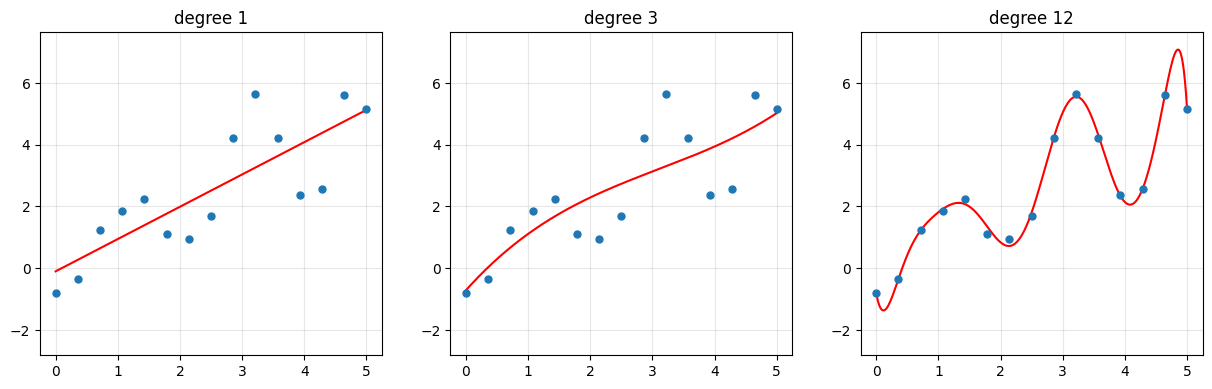

In [11]:
# Polynomial fits: degree 1 vs 3 vs 12 (overfitting), and ridge to the rescue.
x_p, y_p = make_noisy_line(n=15, slope=1.0, intercept=0.0, noise=1.0, seed=5)
y_p = y_p + 0.8 * np.sin(2.5 * x_p)          # make the truth mildly nonlinear

xs = np.linspace(x_p.min(), x_p.max(), 300)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, deg in zip(axes, [1, 3, 12], strict=True):
    V_p = np.vander(x_p, deg + 1)
    c, _ = algebra.least_squares(V_p, y_p)
    ax.scatter(x_p, y_p, zorder=3, s=25)
    ax.plot(xs, np.polyval(c, xs), "r")
    ax.set_ylim(y_p.min() - 2, y_p.max() + 2)
    ax.set_title(f"degree {deg}")
    ax.grid(alpha=0.3)
plt.show()

### ▶ 触って確かめる — 次数を上げると過学習する

同じデータに対し、多項式の**次数**をスライダーで $1 \to 12$ と上げてみましょう。
低次は当てはまりが甘く（過小適合）、高次は点を縫うように暴れます（過学習）。
スライダーのラベルの **訓練 RMSE は次数とともに下がり続ける**のに、曲線はどんどん信用できなくなる —
これが「訓練誤差だけ見て次数を決めてはいけない」理由です（検証データが要る、04→機械学習へ）。

In [12]:
# Same data; drag the polynomial degree and watch overfitting appear.
fig = plotting.plotly_poly_fit_degree(x_p, y_p, degrees=range(1, 13))
fig.show()

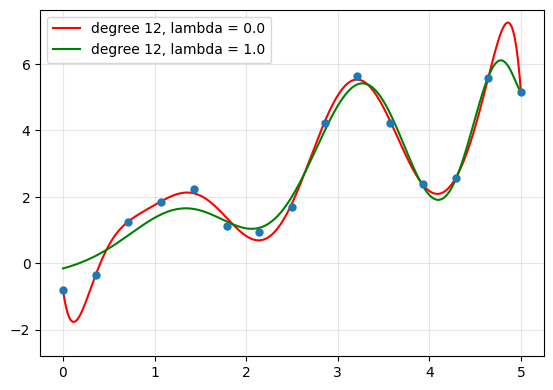

In [13]:
# Ridge tames the degree-12 fit.
V12 = np.vander(x_p, 13)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(x_p, y_p, zorder=3, s=25)
for lam, style in [(0.0, "r-"), (1.0, "g-")]:
    c = algebra.ridge(V12, y_p, lam)
    ax.plot(xs, np.polyval(c, xs), style, label=f"degree 12, lambda = {lam}")
ax.set_ylim(y_p.min() - 2, y_p.max() + 2)
ax.grid(alpha=0.3); ax.legend()
plt.show()

```{admonition} 実社会では
:class: important
最小二乗＝「列空間への正射影」は、データから法則を引き出す最も基本的な道具です。

- 回帰分析・キャリブレーション：観測に最も合う係数を求める（統計・計量経済の土台）。
- 信号処理・センサ融合：ノイズ込みの観測から状態を推定（カルマンフィルタも最小二乗の一族）。
- 機械学習：線形回帰そのもの。リッジ／Lasso の**正則化**は「係数に罰金」で過学習を抑える同じ発想。
- 決定係数 $R^2$：ピタゴラス $\|b\|^2=\|p\|^2+\|r\|^2$ の「説明できた割合」そのもの。

「厳密には解けないが、最も近い答えが欲しい」— 現実のデータ問題はほぼ全部この形をしています。
```

## 10. Exercises

1. $v = (1, 2, 2)$ のノルムを手で計算せよ。$v$ と直交するベクトルを 2 本見つけ、
   その 2 本も互いに直交するように選び直せ。
2. $b = (3, 4)$ を直線 $\mathrm{span}\{(1, 1)\}$ に射影し、残差が直線と直交することを確かめよ。
3. 射影行列 $P = A(A^\top A)^{-1}A^\top$ について $P^2 = P$ を式変形で示せ。
   ランダムな $A$ で数値的にも確認せよ。
4. データ $(0, 1), (1, 2), (2, 4)$ に直線を最小二乗フィットせよ
   (正規方程式を手で立てて解き、`least_squares` で検算)。
5. 上の多項式フィットで、次数を 1〜12 まで動かして「訓練誤差」を計算しプロットせよ。
   次数とともに単調減少することを確認し、それがなぜ過学習の検出に使えないか考えよ。
6. (発展)関数 $f(x) = \sin(\pi x)$ を区間 $[0,1]$ 上の多項式で近似する問題を、
   多数の格子点での最小二乗として解いてみよ。

## 11. Advanced Notes

**正規方程式の導出(微分版)。** $f(x) = \|Ax - b\|^2 = x^\top A^\top A x - 2 b^\top A x + b^\top b$
の勾配は $\nabla f = 2 A^\top A x - 2 A^\top b$。これを 0 と置けば $A^\top A x = A^\top b$。
06 章の「最小二乗 = 最適化」の接続はこの式がそのまま橋になります。

**Cauchy-Schwarz の不等式。** $|v^\top w| \le \|v\| \|w\|$。
証明: 任意の $t$ で $\|v - tw\|^2 \ge 0$。左辺は $t$ の 2 次式なので判別式 $\le 0$、これが主張そのもの。
等号は $v, w$ が平行のとき。これにより $\cos\theta$ の定義が常に $[-1, 1]$ に収まります。

**古典 Gram-Schmidt の数値的弱点。** 浮動小数点では、ほぼ平行なベクトル同士の引き算で
直交性が急速に劣化します(桁落ち)。実務の QR 分解は Householder 鏡映で計算され、
直交性が機械精度で保たれます。`np.linalg.qr` がそれです。

**関数空間への一般化。** 内積は $\langle f, g \rangle = \int_0^1 f(x)g(x)\,dx$ のように
関数にも定義できます。すると「関数の直交」「関数への射影」が意味を持ち、
Fourier 級数は「三角関数という正規直交基底への正射影」にほかなりません。
最小二乗の幾何がそのまま無限次元に持ち上がります。